# 📓 Notebook 06 — Stockout Prediction

> ### 🚨 From Demand Forecasting to Stockout Risk
>
> Now **RetailIQ** moves from:
>
> **“How much demand will we have?”**
>
> to:
>
> **“Is this product likely to run out of stock in the next 7 days?”**
>
> We will build this notebook as a **time-aware binary classification problem**, avoiding **future-data leakage**.

---

## 🎯 What This Notebook Will Cover

### 1️⃣ Data Preparation

* 📂 Load the **feature-engineered data**

### 2️⃣ Problem Understanding

* 🧠 Understand the **stockout prediction problem**
* 🎯 Create the `stockout_next_7_days` target
* ⚖️ Check **class balance**

### 3️⃣ Time-Aware Dataset Construction

* 🗓️ Remove rows that cannot have a **complete 7-day future window**
* 🔍 Define **prediction-time features**
* ⏳ Perform a **time-based train/test split**

### 4️⃣ Model Development

* ⚙️ Build **preprocessing pipeline**
* 📈 Train **Logistic Regression**
* 🌲 Train **Random Forest**
* 🚀 Train **XGBoost**

### 5️⃣ Model Evaluation

Evaluate the models using:

| Metric           | Purpose                                              |
| ---------------- | ---------------------------------------------------- |
| 🎯 **Precision** | How many predicted stockouts were actually stockouts |
| 🔎 **Recall**    | How many actual stockouts were successfully detected |
| ⚖️ **F1-score**  | Balance between Precision and Recall                 |
| 📈 **ROC-AUC**   | Overall ranking/discrimination ability               |
| 📊 **PR-AUC**    | Performance focused on the stockout class            |

### 6️⃣ Model Comparison & Interpretation

* 📋 Compare models
* 🔲 Inspect **confusion matrices**
* 🧩 Analyze **feature importance**
* 🎲 Examine **stockout risk probabilities**

### 7️⃣ Final Outputs

* 💾 Save **model results and predictions**
* 📝 Produce a **final project-ready summary**

---

## ⚠️ Important Prediction Scenario

> **RetailIQ makes the prediction at the end of the current day.**

Therefore, at prediction time, the model is allowed to use:

* 📦 **Current inventory**
* 🛒 **Current units sold/ordered**
* 📊 **Historical demand information**
* 🕐 Other features that are genuinely available **up to the current day**

### 🎯 Prediction Target

The target asks:

> **Will the product's inventory reach zero on any of the next 7 days?**

This means the model predicts:

**Current Day → Next 7 Days**

```text
              PREDICTION TIME
                    │
                    ▼
              End of Current Day
                    │
          ┌─────────┴─────────┐
          │                   │
   Available Information     Future
          │                   │
          ▼                   ▼
 Current Inventory       Next 7 Days
 Historical Demand       ─────────────
 Current Sales/Orders    Stockout?
          │                   │
          └─────── MODEL ─────┘
                    │
                    ▼
          Stockout Risk Prediction
```

### 🚫 Leakage Prevention

The model **must not use information from the future 7-day window as input features**.

Only information available **at the end of the current day** can be used to make the prediction.

---

## 🏁 Final Goal

By the end of **Notebook 06**, RetailIQ should be able to answer:

> **“Given everything we know at the end of today, how likely is this product to stock out within the next 7 days?”**


### Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

### Step 2 — Load Feature-Engineered Dataset
Why

Notebook 04 created the historical demand features that we can reuse for stockout prediction.

In [2]:
df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Dataset shape: (76000, 40)
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00


### Step 3 — Inspect the Dataset
Why

Before creating the target, verify the important inventory and demand columns.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Quarter', 'Day', 'DayofWeek', 'DayOfWeek', 'IsWeekend', 'Promotion_Flag', 'Discount_Pct', 'Price_Difference', 'Price_Ratio', 'Demand_Lag_1', 'Demand_Lag_7', 'Demand_Lag_14', 'Demand_Lag_28', 'Demand_Rolling_Mean_7', 'Demand_Rolling_Mean_14', 'Demand_Rolling_Mean_28', 'Demand_Rolling_Std_7', 'Demand_Lag_2', 'Demand_Change_1', 'Demand_Change_7', 'Inventory_Gap', 'Inventory_Coverage_Days']

First 5 rows:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Demand_Lag_28,Demand_Rolling_Mean_7,Demand_Rolling_Mean_14,Demand_Rolling_Mean_28,Demand_Rolling_Std_7,Demand_Lag_2,Demand_Change_1,Demand_Change_7,Inventory_Gap,Inventory_Coverage_Days
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,...,NaN,NaN,NaN,NaN,NaN,115.0,-31.0,NaN,NaN,NaN
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,...,NaN,NaN,NaN,NaN,NaN,84.0,48.0,NaN,NaN,NaN
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,...,NaN,NaN,NaN,NaN,NaN,132.0,-65.0,NaN,NaN,NaN


### Step 4 — Sort Data Chronologically
Why

Future stockout labels must be created in the correct time order for each store-product combination.

In [4]:
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

print(df[["Store ID", "Product ID", "Date"]].head(10))

  Store ID Product ID       Date
0     S001      P0001 2022-01-01
1     S001      P0001 2022-01-02
2     S001      P0001 2022-01-03
3     S001      P0001 2022-01-04
4     S001      P0001 2022-01-05
5     S001      P0001 2022-01-06
6     S001      P0001 2022-01-07
7     S001      P0001 2022-01-08
8     S001      P0001 2022-01-09
9     S001      P0001 2022-01-10


### Step 5 — Check Inventory Values
Why

A stockout will be defined as inventory reaching zero.

In [5]:
print("Inventory statistics:")
print(df["Inventory Level"].describe())

print("\nZero inventory records:")
print((df["Inventory Level"] == 0).sum())

print("\nNegative inventory records:")
print((df["Inventory Level"] < 0).sum())

Inventory statistics:
count    76000.000000
mean       301.062842
std        226.510161
min          0.000000
25%        136.000000
50%        227.000000
75%        408.000000
max       2267.000000
Name: Inventory Level, dtype: float64

Zero inventory records:
406

Negative inventory records:
0


### Step 6 — Create Future Inventory Columns
Why

To determine whether a stockout occurs during the next 7 days, we need to inspect future inventory — only while creating the target.

In [6]:
group_cols = ["Store ID", "Product ID"]

for i in range(1, 8):
    df[f"Inventory_Next_{i}_Day"] = (
        df.groupby(group_cols)["Inventory Level"]
        .shift(-i)
    )

future_inventory_cols = [
    f"Inventory_Next_{i}_Day"
    for i in range(1, 8)
]

print(df[[
    "Date",
    "Store ID",
    "Product ID",
    "Inventory Level"
] + future_inventory_cols].head(10))

        Date Store ID Product ID  Inventory Level  Inventory_Next_1_Day  \
0 2022-01-01     S001      P0001              195                  93.0   
1 2022-01-02     S001      P0001               93                 274.0   
2 2022-01-03     S001      P0001              274                 132.0   
3 2022-01-04     S001      P0001              132                 319.0   
4 2022-01-05     S001      P0001              319                 190.0   
5 2022-01-06     S001      P0001              190                  92.0   
6 2022-01-07     S001      P0001               92                 308.0   
7 2022-01-08     S001      P0001              308                 212.0   
8 2022-01-09     S001      P0001              212                 403.0   
9 2022-01-10     S001      P0001              403                 315.0   

   Inventory_Next_2_Day  Inventory_Next_3_Day  Inventory_Next_4_Day  \
0                 274.0                 132.0                 319.0   
1                 132.0         

### Step 7 — Create stockout_next_7_days
Why

This is the target variable RetailIQ will predict.

In [7]:
df["stockout_next_7_days"] = (
    df[future_inventory_cols]
    .eq(0)
    .any(axis=1)
    .astype(int)
)

print(
    df["stockout_next_7_days"]
    .value_counts()
    .sort_index()
)

stockout_next_7_days
0    73476
1     2524
Name: count, dtype: int64


### Step 8 — Check Stockout Class Balance
Why

Stockout prediction may be an imbalanced classification problem, so accuracy alone will not be sufficient.

In [8]:
class_counts = df["stockout_next_7_days"].value_counts().sort_index()

class_percent = (
    df["stockout_next_7_days"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
stockout_next_7_days
0    73476
1     2524
Name: count, dtype: int64

Class percentages:
stockout_next_7_days
0    96.678947
1     3.321053
Name: proportion, dtype: float64


### Step 9 — Visualize Stockout Class Distribution
Why

A visual check makes the class imbalance easy to understand.

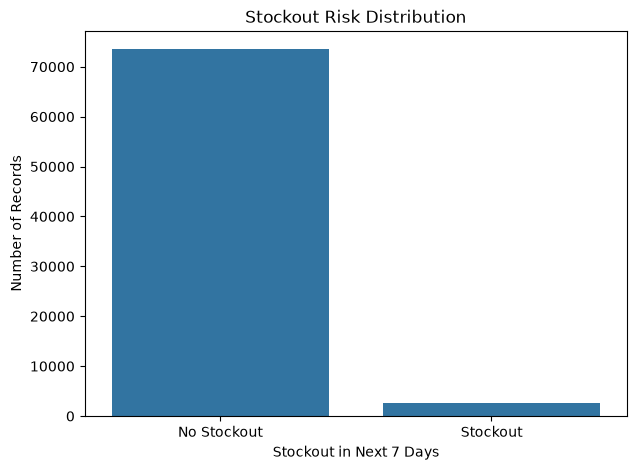

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="stockout_next_7_days"
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout in Next 7 Days")
plt.ylabel("Number of Records")
plt.xticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.show()

### Step 10 — Check Target by Product Category
Why

This helps us understand whether stockout risk differs across categories.

In [10]:
category_stockout = (
    df.groupby("Category")["stockout_next_7_days"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

category_stockout["stockout_rate_%"] = (
    category_stockout["mean"] * 100
)

category_stockout = category_stockout.sort_values(
    "stockout_rate_%",
    ascending=False
)

display(category_stockout)

,Category,count,sum,mean,stockout_rate_%
3,Groceries,30400,1276,0.041974,4.197368
4,Toys,10640,332,0.031203,3.120301
1,Electronics,9120,275,0.030154,3.015351
0,Clothing,12160,341,0.028043,2.804276
2,Furniture,13680,300,0.021930,2.192982


### Step 11 — Check Target by Store
Why

Different stores may experience different stockout patterns.

In [11]:
store_stockout = (
    df.groupby("Store ID")["stockout_next_7_days"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

store_stockout["stockout_rate_%"] = (
    store_stockout["mean"] * 100
)

store_stockout = store_stockout.sort_values(
    "stockout_rate_%",
    ascending=False
)

display(store_stockout)

,Store ID,count,sum,mean,stockout_rate_%
4,S005,15200,579,0.038092,3.809211
1,S002,15200,563,0.037039,3.703947
2,S003,15200,542,0.035658,3.565789
3,S004,15200,487,0.032039,3.203947
0,S001,15200,353,0.023224,2.322368


### Step 12 — Remove Future Target-Construction Columns
Why

**Inventory_Next_1_Day** through **Inventory_Next_7_Day** contain future information. They must never be used as model features.

In [12]:
df_model = df.drop(
    columns=future_inventory_cols
).copy()

print("Shape after removing future inventory columns:")
print(df_model.shape)

Shape after removing future inventory columns:
(76000, 41)


### Step 13 — Remove Rows Without a Complete Future Window
Why

The last 7 days of each store-product series cannot know what happens over the complete next 7 days.

In [13]:
df_model = df_model.dropna(
    subset=["stockout_next_7_days"]
).copy()

print("Shape after removing incomplete future windows:")
print(df_model.shape)

Shape after removing incomplete future windows:
(76000, 41)


### Step 14 — Check Missing Values
Why

Our lag and rolling features have missing values at the beginning of each store-product history.

In [14]:
missing_values = (
    df_model.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values[missing_values > 0])

Demand_Rolling_Mean_28     2800
Demand_Lag_28              2800
Demand_Lag_14              1400
Demand_Rolling_Mean_14     1400
Demand_Change_7            1400
Demand_Rolling_Mean_7       700
Inventory_Gap               700
Demand_Lag_7                700
Demand_Rolling_Std_7        700
Inventory_Coverage_Days     700
Demand_Lag_2                200
Demand_Change_1             200
Demand_Lag_1                100
dtype: int64


### Step 15 — Remove Rows Missing Required Historical Features
Why

We want every model record to have complete historical demand information.

In [15]:
historical_features = [
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7"
]

df_model = df_model.dropna(
    subset=historical_features
).copy()

print("Final modeling dataset shape:", df_model.shape)

Final modeling dataset shape: (73200, 41)


### Step 16 — Verify Target After Cleaning
Why

Removing rows must not accidentally remove the stockout class.

In [16]:
print(
    df_model["stockout_next_7_days"]
    .value_counts()
    .sort_index()
)

print("\nPercentages:")
print(
    df_model["stockout_next_7_days"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

stockout_next_7_days
0    70821
1     2379
Name: count, dtype: int64

Percentages:
stockout_next_7_days
0    96.75
1     3.25
Name: proportion, dtype: float64


### Step 17 — Define Prediction Features
Why

These are variables available at the time RetailIQ makes the stockout prediction.

In [17]:
stockout_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Promotion",
    "Discount",
    "Discount_Pct",
    "Price",
    "Competitor Pricing",
    "Price_Difference",
    "Price_Ratio",
    "Epidemic",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7",
    "Demand_Change_1",
    "Demand_Change_7",
    "Inventory_Gap",
    "Inventory_Coverage_Days"
]

target = "stockout_next_7_days"

print("Number of features:", len(stockout_features))
print("\nTarget:", target)

Number of features: 36

Target: stockout_next_7_days


### Step 18 — Create X and y
Why

**X** contains the information RetailIQ uses to predict risk, while **y** contains the actual future stockout outcome.

In [18]:
X = df_model[stockout_features].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (73200, 36)
y shape: (73200,)

Target distribution:
stockout_next_7_days
0    70821
1     2379
Name: count, dtype: int64


### Step 19 — Sort the Modeling Dataset by Date
Why

Classification must respect the time sequence; we should not randomly mix past and future observations.

In [19]:
df_model = df_model.sort_values(
    "Date"
).reset_index(drop=True)

X = df_model[stockout_features].copy()
y = df_model[target].copy()

print(
    "Date range:",
    df_model["Date"].min(),
    "to",
    df_model["Date"].max()
)

Date range: 2022-01-29 00:00:00 to 2024-01-30 00:00:00


### Step 20 — Define Time-Based Split
Why

The model should learn from the past and be evaluated on future data.

We will use the same approximate forecasting boundary as Notebook 05.

In [20]:
train_end_date = pd.Timestamp("2023-09-05")

train_mask = df_model["Date"] <= train_end_date
test_mask = df_model["Date"] > train_end_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training period:")
print(df_model.loc[train_mask, "Date"].min(),
      "to",
      df_model.loc[train_mask, "Date"].max())

print("\nTesting period:")
print(df_model.loc[test_mask, "Date"].min(),
      "to",
      df_model.loc[test_mask, "Date"].max())

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training period:
2022-01-29 00:00:00 to 2023-09-05 00:00:00

Testing period:
2023-09-06 00:00:00 to 2024-01-30 00:00:00

Training shape: (58500, 36)
Testing shape: (14700, 36)


### Step 21 — Check Class Balance in Train and Test
**Why**

The class distribution can change over time.

In [21]:
print("Training class distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index() * 100
)

print("\nTesting class distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index() * 100
)

Training class distribution:
stockout_next_7_days
0    96.77265
1     3.22735
Name: proportion, dtype: float64

Testing class distribution:
stockout_next_7_days
0    96.659864
1     3.340136
Name: proportion, dtype: float64


### Step 22 — Identify Categorical and Numerical Features
Why

Categorical features require one-hot encoding, while numerical features can be scaled for Logistic Regression.

In [22]:
categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numerical_features = [
    feature
    for feature in stockout_features
    if feature not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

Numerical features:
['Year', 'Month', 'Quarter', 'Day', 'DayOfWeek', 'IsWeekend', 'Promotion', 'Discount', 'Discount_Pct', 'Price', 'Competitor Pricing', 'Price_Difference', 'Price_Ratio', 'Epidemic', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand_Lag_1', 'Demand_Lag_2', 'Demand_Lag_7', 'Demand_Lag_14', 'Demand_Lag_28', 'Demand_Rolling_Mean_7', 'Demand_Rolling_Mean_14', 'Demand_Rolling_Mean_28', 'Demand_Rolling_Std_7', 'Demand_Change_1', 'Demand_Change_7', 'Inventory_Gap', 'Inventory_Coverage_Days']

Number of categorical features: 6
Number of numerical features: 30


### Step 23 — Create Preprocessing Pipeline
Why

The same transformations must be applied consistently to training and testing data.

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

### Step 24 — Calculate Class Weight
**Why**

If stockouts are less frequent than non-stockouts, we can compensate during model training.

In [24]:
class_counts_train = y_train.value_counts()

negative_count = class_counts_train.get(0, 0)
positive_count = class_counts_train.get(1, 0)

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 56612
Positive samples: 1888
scale_pos_weight: 29.985169491525422


### Step 25 — Train Logistic Regression
**Why**

Logistic Regression gives us a simple classification baseline.

In [25]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


### Step 26 — Generate Logistic Regression Predictions
**Why**

We need both class predictions and probabilities for evaluation.

In [26]:
logistic_pred = logistic_model.predict(X_test)

logistic_proba = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")
print("First 10 predictions:", logistic_pred[:10])
print("First 10 probabilities:", logistic_proba[:10])

Predictions generated.
First 10 predictions: [1 0 0 1 1 0 0 0 0 0]
First 10 probabilities: [0.77741958 0.31618121 0.32643453 0.80472354 0.74337925 0.20786241
 0.25501294 0.48074035 0.33089228 0.3434106 ]


### Step 27 — Train Random Forest
**Why**

Random Forest can capture nonlinear relationships between inventory, demand, and stockout risk.

In [27]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=12,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


### Step 28 — Generate Random Forest Predictions

In [28]:
rf_pred = rf_model.predict(X_test)

rf_proba = rf_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")

Predictions generated.


### Step 29 — Train XGBoost Classifier
**Why**

XGBoost can model complex nonlinear relationships and interactions between inventory and demand features.

In [29]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


### Step 30 — Generate XGBoost Predictions

In [30]:
xgb_pred = xgb_model.predict(X_test)

xgb_proba = xgb_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")

Predictions generated.


### Step 31 — Create Evaluation Function
**Why**

We need multiple classification metrics because stockout prediction is not just about overall accuracy.

In [31]:
def evaluate_classifier(
    model_name,
    y_true,
    y_pred,
    y_proba
):
    
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )
    
    pr_auc = average_precision_score(
        y_true,
        y_proba
    )
    
    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

### Step 32 — Evaluate Logistic Regression

In [32]:
logistic_results = evaluate_classifier(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_proba
)

print(logistic_results)

{'Model': 'Logistic Regression', 'Precision': 0.055099463214398486, 'Recall': 0.7107942973523421, 'F1': 0.10227106227106227, 'ROC-AUC': 0.696311350813338, 'PR-AUC': 0.0684171064832625}


### Step 33 — Evaluate Random Forest

In [33]:
rf_results = evaluate_classifier(
    "Random Forest",
    y_test,
    rf_pred,
    rf_proba
)

print(rf_results)

{'Model': 'Random Forest', 'Precision': 0.09454545454545454, 'Recall': 0.31771894093686354, 'F1': 0.14572629612330687, 'ROC-AUC': 0.7639757882722276, 'PR-AUC': 0.08442340034028352}


### Step 34 — Evaluate XGBoost

In [34]:
xgb_results = evaluate_classifier(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_proba
)

print(xgb_results)

{'Model': 'XGBoost', 'Precision': 0.125, 'Recall': 0.024439918533604887, 'F1': 0.04088586030664395, 'ROC-AUC': 0.7447752270834913, 'PR-AUC': 0.08393673032702074}


### Step 35 — Compare Classification Models
**Why**

This gives us one table containing the main stockout-prediction metrics.

In [35]:
classification_results = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

classification_results = classification_results.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(classification_results)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.094545,0.317719,0.145726,0.763976,0.084423
1,Logistic Regression,0.055099,0.710794,0.102271,0.696311,0.068417
2,XGBoost,0.125000,0.024440,0.040886,0.744775,0.083937


### Step 36 — Classification Reports
**Why**

The classification report shows performance separately for stockout and non-stockout classes.

In [36]:
print("=== Logistic Regression ===")
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["No Stockout", "Stockout"],
        zero_division=0
    )
)

print("\n=== Random Forest ===")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Stockout", "Stockout"],
        zero_division=0
    )
)

print("\n=== XGBoost ===")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["No Stockout", "Stockout"],
        zero_division=0
    )
)

=== Logistic Regression ===
              precision    recall  f1-score   support

 No Stockout       0.98      0.58      0.73     14209
    Stockout       0.06      0.71      0.10       491

    accuracy                           0.58     14700
   macro avg       0.52      0.64      0.42     14700
weighted avg       0.95      0.58      0.71     14700


=== Random Forest ===
              precision    recall  f1-score   support

 No Stockout       0.97      0.89      0.93     14209
    Stockout       0.09      0.32      0.15       491

    accuracy                           0.88     14700
   macro avg       0.53      0.61      0.54     14700
weighted avg       0.94      0.88      0.91     14700


=== XGBoost ===
              precision    recall  f1-score   support

 No Stockout       0.97      0.99      0.98     14209
    Stockout       0.12      0.02      0.04       491

    accuracy                           0.96     14700
   macro avg       0.55      0.51      0.51     14700
weight

### Step 37 — Confusion Matrix: Logistic Regression

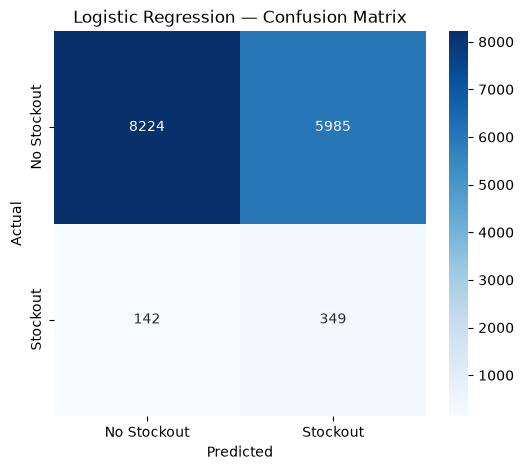

In [37]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stockout", "Stockout"],
    yticklabels=["No Stockout", "Stockout"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 38 — Confusion Matrix: Random Forest

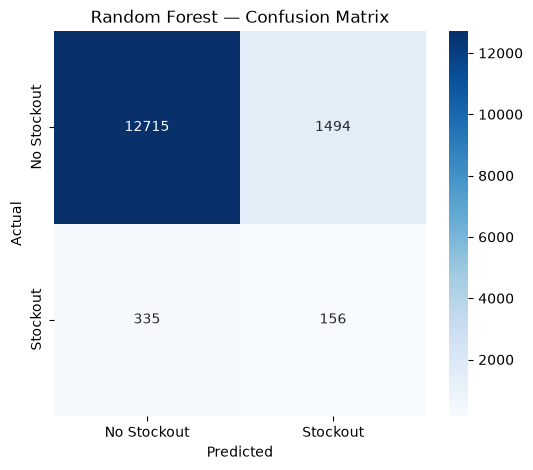

In [38]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stockout", "Stockout"],
    yticklabels=["No Stockout", "Stockout"]
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 39 — Confusion Matrix: XGBoost

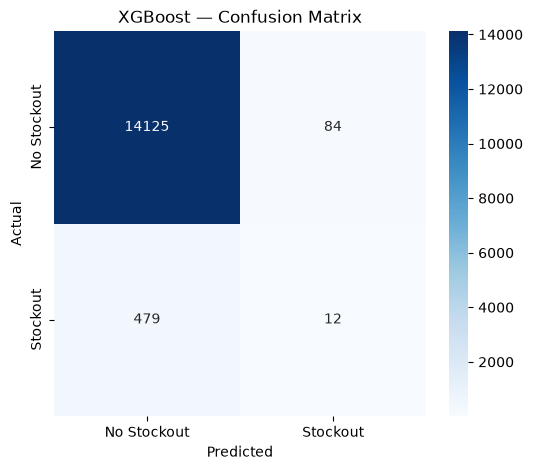

In [39]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stockout", "Stockout"],
    yticklabels=["No Stockout", "Stockout"]
)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 40 — Plot ROC Curves
**Why**

ROC-AUC measures how well the models separate stockout and non-stockout cases across probability thresholds.

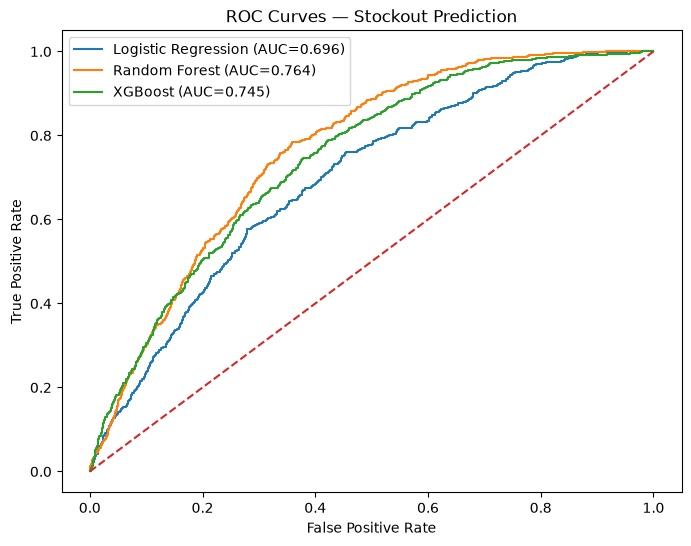

In [40]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_proba
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, logistic_proba):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_proba):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Stockout Prediction")
plt.legend()

plt.show()

### Step 41 — Plot Precision-Recall Curves
***Why***

PR-AUC is particularly useful when stockouts are relatively rare.

In [ ]:
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    logistic_proba
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_proba
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC={average_precision_score(y_test, logistic_proba):.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (PR-AUC={average_precision_score(y_test, rf_proba):.3f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC={average_precision_score(y_test, xgb_proba):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Stockout Prediction")
plt.legend()

plt.show()

### Step 42 — Extract XGBoost Feature Importance
**Why**

RetailIQ should not only predict stockout risk; later we need to explain why the risk is high.

In [41]:
xgb_preprocessor = xgb_model.named_steps["preprocessor"]
xgb_classifier = xgb_model.named_steps["classifier"]

feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance.head(20)
)

,Feature,Importance
0,categorical__Product ID_P0018,0.043135
1,categorical__Category_Furniture,0.042397
2,numerical__Units Ordered,0.040355
3,categorical__Product ID_P0008,0.029636
4,categorical__Category_Groceries,0.029332
5,categorical__Product ID_P0016,0.024463
6,categorical__Product ID_P0010,0.020328
7,numerical__Inventory_Gap,0.019526
8,categorical__Product ID_P0004,0.019461
9,categorical__Product ID_P0012,0.018182


### Step 43 — Plot Top 20 XGBoost Features

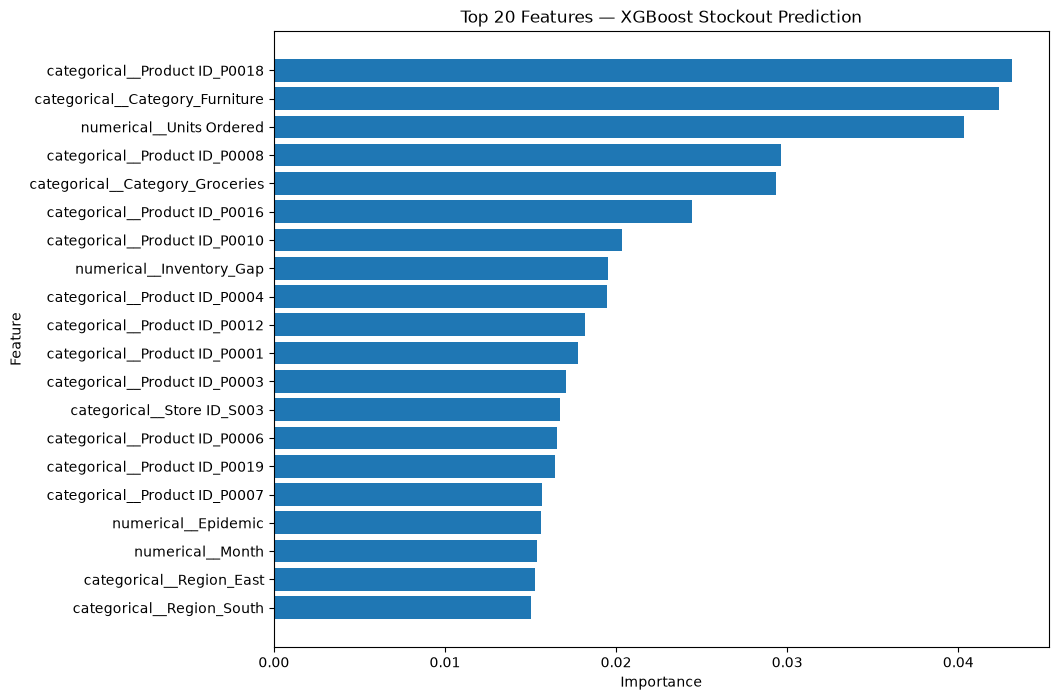

In [42]:
top_features = (
    feature_importance
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features — XGBoost Stockout Prediction")

plt.show()

### Step 44 — Create Test Prediction DataFrame
**Why**

We need a business-friendly table containing the actual stockout outcome and predicted risk.

In [43]:
stockout_predictions = df_model.loc[
    test_mask,
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "Inventory Level",
        "Units Sold",
        "Units Ordered",
        "Demand_Lag_1",
        "Demand_Rolling_Mean_7",
        "Inventory_Coverage_Days",
        "stockout_next_7_days"
    ]
].copy()

stockout_predictions["XGB_Stockout_Probability"] = (
    xgb_proba
)

stockout_predictions["XGB_Predicted_Stockout"] = (
    xgb_pred
)

stockout_predictions.head()

,Date,Store ID,Product ID,Category,Inventory Level,Units Sold,Units Ordered,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,stockout_next_7_days,XGB_Stockout_Probability,XGB_Predicted_Stockout
58500,2023-09-06,S005,P0007,Groceries,151,151,361,117.0,111.714286,1.351662,0,0.166917,0
58501,2023-09-06,S005,P0019,Furniture,190,43,0,74.0,85.714286,2.216667,0,0.033246,0
58502,2023-09-06,S001,P0012,Groceries,254,67,0,174.0,138.428571,1.834881,0,0.012453,0
58503,2023-09-06,S005,P0016,Toys,326,120,553,100.0,81.571429,3.996497,0,0.105787,0
58504,2023-09-06,S003,P0002,Groceries,125,59,0,96.0,108.428571,1.152833,0,0.023305,0


### Step 45 — Sort by Highest Stockout Risk
**Why**

This is the beginning of RetailIQ's future inventory-risk dashboard.

In [44]:
high_risk_products = stockout_predictions.sort_values(
    "XGB_Stockout_Probability",
    ascending=False
).reset_index(drop=True)

display(
    high_risk_products.head(20)
)

,Date,Store ID,Product ID,Category,Inventory Level,Units Sold,Units Ordered,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,stockout_next_7_days,XGB_Stockout_Probability,XGB_Predicted_Stockout
0,2023-09-22,S002,P0013,Groceries,335,210,540,93.0,134.571429,2.489384,0,0.919883,1
1,2024-01-12,S005,P0015,Groceries,221,189,412,109.0,78.285714,2.822993,0,0.907055,1
2,2023-09-15,S001,P0016,Groceries,294,143,0,154.0,127.000000,2.314961,0,0.857799,1
3,2023-10-15,S003,P0015,Groceries,325,154,722,82.0,104.000000,3.125000,0,0.832588,1
4,2024-01-12,S005,P0009,Groceries,136,136,764,115.0,84.285714,1.613559,0,0.826286,1
5,2023-10-26,S002,P0011,Groceries,158,158,459,96.0,71.571429,2.207585,1,0.823498,1
6,2023-09-15,S003,P0015,Groceries,495,77,0,142.0,115.285714,4.293680,0,0.823102,1
7,2024-01-11,S005,P0009,Groceries,235,99,0,105.0,78.142857,3.007313,0,0.792151,1
8,2023-09-20,S002,P0003,Groceries,168,108,0,108.0,128.428571,1.308120,0,0.789645,1
9,2023-09-13,S001,P0016,Groceries,54,54,0,187.0,136.571429,0.395397,0,0.780653,1


### Step 46 — Analyze High-Risk Products

In [45]:
high_risk_summary = (
    high_risk_products
    .head(20)
    [
        [
            "Date",
            "Store ID",
            "Product ID",
            "Category",
            "Inventory Level",
            "Demand_Lag_1",
            "Demand_Rolling_Mean_7",
            "Inventory_Coverage_Days",
            "XGB_Stockout_Probability"
        ]
    ]
)

display(high_risk_summary)

,Date,Store ID,Product ID,Category,Inventory Level,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,XGB_Stockout_Probability
0,2023-09-22,S002,P0013,Groceries,335,93.0,134.571429,2.489384,0.919883
1,2024-01-12,S005,P0015,Groceries,221,109.0,78.285714,2.822993,0.907055
2,2023-09-15,S001,P0016,Groceries,294,154.0,127.000000,2.314961,0.857799
3,2023-10-15,S003,P0015,Groceries,325,82.0,104.000000,3.125000,0.832588
4,2024-01-12,S005,P0009,Groceries,136,115.0,84.285714,1.613559,0.826286
5,2023-10-26,S002,P0011,Groceries,158,96.0,71.571429,2.207585,0.823498
6,2023-09-15,S003,P0015,Groceries,495,142.0,115.285714,4.293680,0.823102
7,2024-01-11,S005,P0009,Groceries,235,105.0,78.142857,3.007313,0.792151
8,2023-09-20,S002,P0003,Groceries,168,108.0,128.428571,1.308120,0.789645
9,2023-09-13,S001,P0016,Groceries,54,187.0,136.571429,0.395397,0.780653


### Step 47 — Save Classification Results
**Why**

The model comparison will later be useful for documentation and portfolio reporting.

In [46]:
classification_results.to_csv(
    "../data/processed/stockout_model_results.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_model_results.csv"
)

Saved: ../data/processed/stockout_model_results.csv


### Step 48 — Save Stockout Predictions

In [47]:
stockout_predictions.to_csv(
    "../data/processed/stockout_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_predictions.csv"
)

Saved: ../data/processed/stockout_predictions.csv


### Step 49 — Save Feature Importance

In [48]:
feature_importance.to_csv(
    "../data/processed/stockout_feature_importance.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_feature_importance.csv"
)

Saved: ../data/processed/stockout_feature_importance.csv


### Step 50 — Final Stockout Prediction Summary
**Why**

This gives us the key information we will carry into the next RetailIQ modules.

In [49]:
print("=" * 70)
print("RETAILIQ — STOCKOUT PREDICTION SUMMARY")
print("=" * 70)

print("\nDataset:")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nStockout distribution:")
print(
    y.value_counts()
    .sort_index()
)

print("\nModel comparison:")
display(classification_results)

print("\nTop 10 important features:")
display(
    feature_importance.head(10)
)

print("\nSaved files:")
print("- stockout_model_results.csv")
print("- stockout_predictions.csv")
print("- stockout_feature_importance.csv")

RETAILIQ — STOCKOUT PREDICTION SUMMARY

Dataset:
Training rows: 58500
Testing rows: 14700

Stockout distribution:
stockout_next_7_days
0    70821
1     2379
Name: count, dtype: int64

Model comparison:


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.094545,0.317719,0.145726,0.763976,0.084423
1,Logistic Regression,0.055099,0.710794,0.102271,0.696311,0.068417
2,XGBoost,0.125000,0.024440,0.040886,0.744775,0.083937



Top 10 important features:


,Feature,Importance
0,categorical__Product ID_P0018,0.043135
1,categorical__Category_Furniture,0.042397
2,numerical__Units Ordered,0.040355
3,categorical__Product ID_P0008,0.029636
4,categorical__Category_Groceries,0.029332
5,categorical__Product ID_P0016,0.024463
6,categorical__Product ID_P0010,0.020328
7,numerical__Inventory_Gap,0.019526
8,categorical__Product ID_P0004,0.019461
9,categorical__Product ID_P0012,0.018182



Saved files:
- stockout_model_results.csv
- stockout_predictions.csv
- stockout_feature_importance.csv


### 🔧 Notebook 06 — Refinement

Continue after Step 50.

### Step 51 — Create a Validation Set
**Why**

We need a separate historical period to choose the probability threshold without using the final test set.

In [50]:
validation_end_date = pd.Timestamp("2023-06-30")

train_mask_refined = (
    df_model["Date"] <= validation_end_date
)

validation_mask = (
    (df_model["Date"] > validation_end_date) &
    (df_model["Date"] <= train_end_date)
)

test_mask_refined = (
    df_model["Date"] > train_end_date
)

X_train_refined = df_model.loc[
    train_mask_refined,
    stockout_features
].copy()

y_train_refined = df_model.loc[
    train_mask_refined,
    target
].copy()

X_validation = df_model.loc[
    validation_mask,
    stockout_features
].copy()

y_validation = df_model.loc[
    validation_mask,
    target
].copy()

X_test_refined = df_model.loc[
    test_mask_refined,
    stockout_features
].copy()

y_test_refined = df_model.loc[
    test_mask_refined,
    target
].copy()

print("Training:")
print(
    df_model.loc[train_mask_refined, "Date"].min(),
    "to",
    df_model.loc[train_mask_refined, "Date"].max()
)

print("\nValidation:")
print(
    df_model.loc[validation_mask, "Date"].min(),
    "to",
    df_model.loc[validation_mask, "Date"].max()
)

print("\nTesting:")
print(
    df_model.loc[test_mask_refined, "Date"].min(),
    "to",
    df_model.loc[test_mask_refined, "Date"].max()
)

print("\nShapes:")
print("Train:", X_train_refined.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test_refined.shape)

Training:
2022-01-29 00:00:00 to 2023-06-30 00:00:00

Validation:
2023-07-01 00:00:00 to 2023-09-05 00:00:00

Testing:
2023-09-06 00:00:00 to 2024-01-30 00:00:00

Shapes:
Train: (51800, 36)
Validation: (6700, 36)
Test: (14700, 36)


### Step 52 — Check Validation Class Balance
**Why**

We need to make sure the validation period contains enough stockout cases.

In [51]:
print("Validation class distribution:")

print(
    y_validation.value_counts()
)

print("\nValidation percentages:")

print(
    y_validation.value_counts(normalize=True) * 100
)

Validation class distribution:
stockout_next_7_days
0    6499
1     201
Name: count, dtype: int64

Validation percentages:
stockout_next_7_days
0    97.0
1     3.0
Name: proportion, dtype: float64


### Step 53 — Recalculate Class Weight
**Why**

The refined training period has a different number of positive examples.

In [52]:
train_class_counts = y_train_refined.value_counts()

negative_count = train_class_counts.get(0, 0)
positive_count = train_class_counts.get(1, 0)

scale_pos_weight_refined = (
    negative_count / positive_count
)

print("Negative:", negative_count)
print("Positive:", positive_count)
print(
    "scale_pos_weight:",
    scale_pos_weight_refined
)

Negative: 50113
Positive: 1687
scale_pos_weight: 29.70539419087137


### Step 54 — Train Refined Logistic Regression
**Why**

We need models trained only on the refined training period before threshold selection.

In [53]:
logistic_model_refined = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model_refined.fit(
    X_train_refined,
    y_train_refined
)

print("Refined Logistic Regression trained.")

Refined Logistic Regression trained.


### Step 55 — Train Refined Random Forest

In [54]:
rf_model_refined = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=12,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model_refined.fit(
    X_train_refined,
    y_train_refined
)

print("Refined Random Forest trained.")

Refined Random Forest trained.


### Step 56 — Train Refined XGBoost

In [55]:
xgb_model_refined = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight_refined,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model_refined.fit(
    X_train_refined,
    y_train_refined
)

print("Refined XGBoost trained.")

Refined XGBoost trained.


### Step 56 — Train Refined XGBoost

In [56]:
xgb_model_refined = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight_refined,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model_refined.fit(
    X_train_refined,
    y_train_refined
)

print("Refined XGBoost trained.")

Refined XGBoost trained.


### Step 57 — Generate Validation Probabilities
**Why**

We will use validation probabilities to determine useful classification thresholds.

In [57]:
logistic_val_proba = (
    logistic_model_refined
    .predict_proba(X_validation)[:, 1]
)

rf_val_proba = (
    rf_model_refined
    .predict_proba(X_validation)[:, 1]
)

xgb_val_proba = (
    xgb_model_refined
    .predict_proba(X_validation)[:, 1]
)

print("Validation probabilities generated.")

Validation probabilities generated.


### Step 58 — Find the Best F1 Threshold
**Why**

The default threshold of 0.50 is arbitrary; we should determine a threshold from validation data.

In [58]:
def find_best_threshold(
    y_true,
    probabilities
):
    
    thresholds = np.arange(
        0.05,
        0.96,
        0.01
    )
    
    results = []
    
    for threshold in thresholds:
        
        predictions = (
            probabilities >= threshold
        ).astype(int)
        
        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )
        
        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )
        
        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )
        
        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
    
    threshold_df = pd.DataFrame(results)
    
    best_row = threshold_df.loc[
        threshold_df["F1"].idxmax()
    ]
    
    return threshold_df, best_row

### Step 59 — Tune Logistic Regression Threshold

In [59]:
logistic_threshold_results, logistic_best = (
    find_best_threshold(
        y_validation,
        logistic_val_proba
    )
)

print("Best Logistic Regression threshold:")
display(
    logistic_best.to_frame().T
)

Best Logistic Regression threshold:


,Threshold,Precision,Recall,F1
60,0.65,0.140401,0.243781,0.178182


### Step 60 — Tune Random Forest Threshold

In [60]:
rf_threshold_results, rf_best = (
    find_best_threshold(
        y_validation,
        rf_val_proba
    )
)

print("Best Random Forest threshold:")
display(
    rf_best.to_frame().T
)

Best Random Forest threshold:


,Threshold,Precision,Recall,F1
51,0.56,0.12931,0.223881,0.163934


### Step 61 — Tune XGBoost Threshold

In [61]:
xgb_threshold_results, xgb_best = (
    find_best_threshold(
        y_validation,
        xgb_val_proba
    )
)

print("Best XGBoost threshold:")
display(
    xgb_best.to_frame().T
)

Best XGBoost threshold:


,Threshold,Precision,Recall,F1
15,0.2,0.097917,0.233831,0.138032


### Step 62 — Visualize Threshold vs F1
**Why**

This shows how sensitive stockout detection is to the probability threshold.

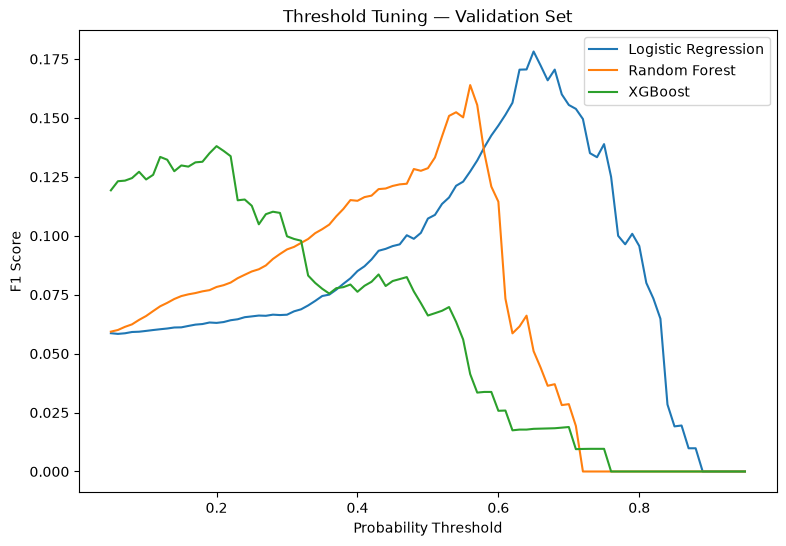

In [62]:
plt.figure(figsize=(9, 6))

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["F1"],
    label="Logistic Regression"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["F1"],
    label="Random Forest"
)

plt.plot(
    xgb_threshold_results["Threshold"],
    xgb_threshold_results["F1"],
    label="XGBoost"
)

plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning — Validation Set")
plt.legend()

plt.show()

### Step 63 — Extract Selected Thresholds

In [63]:
logistic_threshold = logistic_best["Threshold"]
rf_threshold = rf_best["Threshold"]
xgb_threshold = xgb_best["Threshold"]

print("Logistic threshold:", logistic_threshold)
print("Random Forest threshold:", rf_threshold)
print("XGBoost threshold:", xgb_threshold)

Logistic threshold: 0.6500000000000001
Random Forest threshold: 0.5600000000000002
XGBoost threshold: 0.2


### Step 64 — Generate Final Test Probabilities
**Why**

The final test set must remain untouched while we select the thresholds.

In [64]:
logistic_test_proba_refined = (
    logistic_model_refined
    .predict_proba(X_test_refined)[:, 1]
)

rf_test_proba_refined = (
    rf_model_refined
    .predict_proba(X_test_refined)[:, 1]
)

xgb_test_proba_refined = (
    xgb_model_refined
    .predict_proba(X_test_refined)[:, 1]
)

### Step 65 — Apply Tuned Thresholds

In [65]:
logistic_test_pred_tuned = (
    logistic_test_proba_refined >= logistic_threshold
).astype(int)

rf_test_pred_tuned = (
    rf_test_proba_refined >= rf_threshold
).astype(int)

xgb_test_pred_tuned = (
    xgb_test_proba_refined >= xgb_threshold
).astype(int)

print("Tuned test predictions generated.")

Tuned test predictions generated.


### Step 66 — Evaluate Tuned Models

In [66]:
logistic_tuned_results = evaluate_classifier(
    "Logistic Regression — Tuned",
    y_test_refined,
    logistic_test_pred_tuned,
    logistic_test_proba_refined
)

rf_tuned_results = evaluate_classifier(
    "Random Forest — Tuned",
    y_test_refined,
    rf_test_pred_tuned,
    rf_test_proba_refined
)

xgb_tuned_results = evaluate_classifier(
    "XGBoost — Tuned",
    y_test_refined,
    xgb_test_pred_tuned,
    xgb_test_proba_refined
)

tuned_results = pd.DataFrame([
    logistic_tuned_results,
    rf_tuned_results,
    xgb_tuned_results
])

display(tuned_results)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression — Tuned,0.072563,0.344196,0.119858,0.694502,0.068020
1,Random Forest — Tuned,0.093682,0.087576,0.090526,0.762515,0.087027
2,XGBoost — Tuned,0.110672,0.171079,0.134400,0.746688,0.083780


### Step 67 — Compare Default vs Tuned Models
Why

This demonstrates whether threshold tuning actually improved stockout detection.

In [67]:
default_results = classification_results.copy()

default_results["Evaluation"] = "Default Threshold"

tuned_results_comparison = tuned_results.copy()

tuned_results_comparison["Evaluation"] = (
    "Validation-Tuned Threshold"
)

threshold_comparison = pd.concat(
    [
        default_results,
        tuned_results_comparison
    ],
    ignore_index=True
)

display(
    threshold_comparison[
        [
            "Model",
            "Evaluation",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
)

,Model,Evaluation,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,Default Threshold,0.094545,0.317719,0.145726,0.763976,0.084423
1,Logistic Regression,Default Threshold,0.055099,0.710794,0.102271,0.696311,0.068417
2,XGBoost,Default Threshold,0.125000,0.024440,0.040886,0.744775,0.083937
3,Logistic Regression — Tuned,Validation-Tuned Threshold,0.072563,0.344196,0.119858,0.694502,0.068020
4,Random Forest — Tuned,Validation-Tuned Threshold,0.093682,0.087576,0.090526,0.762515,0.087027
5,XGBoost — Tuned,Validation-Tuned Threshold,0.110672,0.171079,0.134400,0.746688,0.083780


### Step 68 — Final Confusion Matrix for Tuned XGBoost

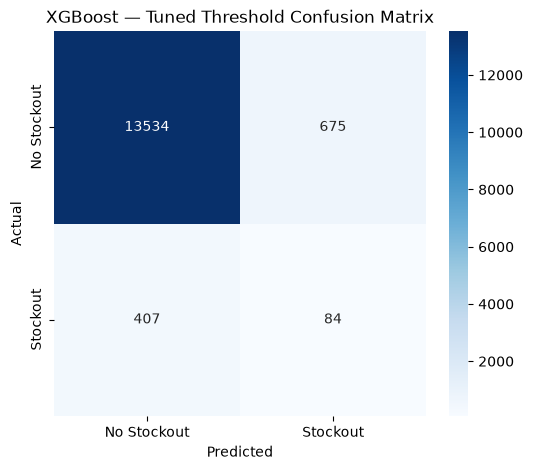

In [69]:
cm_xgb_tuned = confusion_matrix(
    y_test_refined,
    xgb_test_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stockout", "Stockout"],
    yticklabels=["No Stockout", "Stockout"]
)

plt.title(
    "XGBoost — Tuned Threshold Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 69 — Create Final Stockout Risk Table
**Why**

This becomes an important input for the future **Inventory Engine and Power BI dashboard**.

In [70]:
final_stockout_predictions = df_model.loc[
    test_mask_refined,
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Inventory Level",
        "Units Sold",
        "Units Ordered",
        "Demand_Lag_1",
        "Demand_Rolling_Mean_7",
        "Inventory_Coverage_Days",
        target
    ]
].copy()

final_stockout_predictions[
    "Stockout_Probability"
] = xgb_test_proba_refined

final_stockout_predictions[
    "Predicted_Stockout"
] = xgb_test_pred_tuned

final_stockout_predictions = (
    final_stockout_predictions
    .sort_values(
        "Stockout_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_stockout_predictions.head(20)
)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,stockout_next_7_days,Stockout_Probability,Predicted_Stockout
0,2024-01-12,S005,P0015,Groceries,North,221,189,412,109.0,78.285714,2.822993,0,0.925275,1
1,2023-10-24,S005,P0009,Groceries,North,446,38,0,78.0,99.142857,4.498559,0,0.840659,1
2,2023-09-22,S002,P0013,Groceries,South,335,210,540,93.0,134.571429,2.489384,0,0.813895,1
3,2023-09-20,S002,P0019,Clothing,South,64,64,0,200.0,107.428571,0.595745,0,0.805921,1
4,2023-09-19,S005,P0016,Toys,North,584,130,0,105.0,114.142857,5.116395,0,0.803313,1
5,2023-10-02,S001,P0007,Groceries,North,184,184,843,196.0,122.000000,1.508197,0,0.795016,1
6,2023-09-23,S004,P0002,Groceries,West,254,242,488,101.0,100.285714,2.532764,0,0.789929,1
7,2024-01-12,S005,P0009,Groceries,North,136,136,764,115.0,84.285714,1.613559,0,0.788552,1
8,2023-10-20,S002,P0011,Groceries,South,58,35,0,97.0,86.142857,0.673300,1,0.770030,1
9,2023-11-02,S002,P0019,Clothing,South,172,172,749,127.0,101.714286,1.691011,0,0.766318,1


### Step 70 — Save Final Stockout Risk Predictions

In [71]:
final_stockout_predictions.to_csv(
    "../data/processed/final_stockout_risk_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/final_stockout_risk_predictions.csv"
)

Saved: ../data/processed/final_stockout_risk_predictions.csv


### Step 71 — Save Threshold Results

In [72]:
threshold_comparison.to_csv(
    "../data/processed/stockout_threshold_comparison.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_threshold_comparison.csv"
)

Saved: ../data/processed/stockout_threshold_comparison.csv


### Step 72 — Final Notebook 06 Summary

In [73]:
print("=" * 75)
print("RETAILIQ — NOTEBOOK 06 STOCKOUT PREDICTION")
print("=" * 75)

print("\nFinal Target:")
print("stockout_next_7_days")

print("\nFinal Dataset:")
print(
    "Rows:",
    len(df_model)
)

print("\nStockout Rate:")
print(
    f"{y.mean() * 100:.2f}%"
)

print("\nTuned Model Results:")
display(
    tuned_results
)

print("\nSelected Thresholds:")
print(
    "Logistic Regression:",
    logistic_threshold
)

print(
    "Random Forest:",
    rf_threshold
)

print(
    "XGBoost:",
    xgb_threshold
)

print("\nSaved Files:")
print("- stockout_model_results.csv")
print("- stockout_predictions.csv")
print("- stockout_feature_importance.csv")
print("- final_stockout_risk_predictions.csv")
print("- stockout_threshold_comparison.csv")

RETAILIQ — NOTEBOOK 06 STOCKOUT PREDICTION

Final Target:
stockout_next_7_days

Final Dataset:
Rows: 73200

Stockout Rate:
3.25%

Tuned Model Results:


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression — Tuned,0.072563,0.344196,0.119858,0.694502,0.068020
1,Random Forest — Tuned,0.093682,0.087576,0.090526,0.762515,0.087027
2,XGBoost — Tuned,0.110672,0.171079,0.134400,0.746688,0.083780



Selected Thresholds:
Logistic Regression: 0.6500000000000001
Random Forest: 0.5600000000000002
XGBoost: 0.2

Saved Files:
- stockout_model_results.csv
- stockout_predictions.csv
- stockout_feature_importance.csv
- final_stockout_risk_predictions.csv
- stockout_threshold_comparison.csv
